# ST1504 CA2 Part B: C51 Pendulum Control and Gravity-Specific Tuning

## Objective

The objective is to train and evaluate one fixed **C51 Distributional DQN architecture** for the Pendulum environment, then determine suitable hyperparameters for four gravity conditions:

- Anti-gravity, $g=-10$
- Free-fall, $g=0$
- Default gravity, $g=10$
- Supergravity, $g=15$

Due to time and computational constraints, a full architecture comparison is outside the revised scope. C51 is therefore retained as the common architecture, and the experiment focuses on whether gravity-specific tuning improves performance over the same untuned C51 benchmark.

Kayden is responsible for Default and Supergravity. The partner is responsible for Anti-gravity and Free-fall. Both members use the same C51 class, training loop, evaluation method and random seeds.


In [1]:
import gym
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from collections import deque
from tensorflow.keras import layers

print("Gym version:", gym.__version__)
print("TensorFlow version:", tf.__version__)
import json
from pathlib import Path


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Gym version: 0.25.2
TensorFlow version: 2.10.0


## Environment Setup

Unlike supervised learning tasks, reinforcement learning does not begin with a fixed dataset. Instead, training data is generated through interactions between the agent and its environment.

The OpenAI Gym Pendulum environment is created as the data source for this project. During each interaction, the environment provides the agent with a state. The agent selects an action, receives a reward and observes the resulting next state.

The default gravity setting will first be used to explore the environment and develop the baseline DQN agent.

In [2]:
env = gym.make("Pendulum-v1")

state = env.reset()

print("Environment:", env)
print("Initial state:", state)
print("State shape:", state.shape)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Default gravity:", env.unwrapped.g)

env.close()

Environment: <TimeLimit<OrderEnforcing<StepAPICompatibility<PassiveEnvChecker<PendulumEnv<Pendulum-v1>>>>>>
Initial state: [ 0.7917585   0.6108343  -0.48316395]
State shape: (3,)
Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Default gravity: 10.0


c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


# Exploratory Data Analysis (EDA)
### Environment Structure

The Pendulum environment represents each state using three numerical observations:

- The cosine of the pendulum angle
- The sine of the pendulum angle
- The angular velocity of the pendulum

The first two observations range from **-1 to 1**, while angular velocity ranges from **-8 to 8**. Each state therefore has a shape of **(3,)**.

The original action consists of one continuous torque value ranging from **-2 to 2**. Since DQN requires discrete actions, this action space will later be discretised during preprocessing.

Each episode has a maximum duration of **200 time steps**.

In [3]:
env = gym.make("Pendulum-v1")

print("Observation shape:", env.observation_space.shape)
print("Observation minimum values:", env.observation_space.low)
print("Observation maximum values:", env.observation_space.high)

print("Action shape:", env.action_space.shape)
print("Action minimum value:", env.action_space.low)
print("Action maximum value:", env.action_space.high)

print("Maximum episode length:", env.spec.max_episode_steps)
print("Gravity:", env.unwrapped.g)

env.close()

Observation shape: (3,)
Observation minimum values: [-1. -1. -8.]
Observation maximum values: [1. 1. 8.]
Action shape: (1,)
Action minimum value: [-2.]
Action maximum value: [2.]
Maximum episode length: 200
Gravity: 10.0


### Collection of Random-Agent Interaction Data

Unlike a traditional dataset, reinforcement learning data is generated when an agent interacts with the environment.

A random agent was used to complete multiple episodes. At each time step, the following information was recorded:

- Current state
- Selected torque
- Reward received
- Total episodic return

This exploratory data will be used to examine the distributions of the observations, actions and rewards before developing the DQN agent.

In [4]:
env = gym.make("Pendulum-v1")
state = env.reset(seed=42)

number_of_episodes = 50

collected_states = []
collected_actions = []
collected_rewards = []
episode_returns = []

for episode in range(number_of_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()

        next_state, reward, done, info = env.step(action)

        collected_states.append(state)
        collected_actions.append(action[0])
        collected_rewards.append(reward)

        total_reward += reward
        state = next_state

    episode_returns.append(total_reward)

env.close()

collected_states = np.array(collected_states)
collected_actions = np.array(collected_actions)
collected_rewards = np.array(collected_rewards)
episode_returns = np.array(episode_returns)

print("Collected states:", collected_states.shape)
print("Collected actions:", collected_actions.shape)
print("Collected rewards:", collected_rewards.shape)
print("Episode returns:", episode_returns.shape)

Collected states: (10000, 3)
Collected actions: (10000,)
Collected rewards: (10000,)
Episode returns: (50,)


### Random Interaction Data

A random agent was used to collect 10,000 states, 10,000 actions and 10,000 rewards across 50 episodes. This provides an initial understanding of the environment before training the C51 agent.

No missing or infinite values were detected in the states, actions or rewards. Therefore, the collected interaction data was suitable for exploratory analysis and preprocessing.

### Interaction Data Quality

The randomly collected states, actions and rewards were checked for missing and infinite values.

Reinforcement learning environments normally generate valid numerical observations. However, this check is still important because invalid values could cause unstable gradients or prevent the DQN from training correctly.

If no missing or infinite values are found, all collected interactions can be retained for exploratory analysis.

In [5]:
print(
    "Missing state values:",
    np.isnan(collected_states).sum()
)

print(
    "Infinite state values:",
    np.isinf(collected_states).sum()
)

print(
    "Missing action values:",
    np.isnan(collected_actions).sum()
)

print(
    "Infinite action values:",
    np.isinf(collected_actions).sum()
)

print(
    "Missing reward values:",
    np.isnan(collected_rewards).sum()
)

print(
    "Infinite reward values:",
    np.isinf(collected_rewards).sum()
)

Missing state values: 0
Infinite state values: 0
Missing action values: 0
Infinite action values: 0
Missing reward values: 0
Infinite reward values: 0


### Distribution of State Observations

The distributions of the three state observations were examined using histograms.

The cosine and sine observations describe the pendulum’s angular position, while angular velocity describes the speed and direction of its rotation.

This analysis helps identify the ranges and distributions experienced by a random agent. It also indicates whether state normalisation may be useful before DQN training.

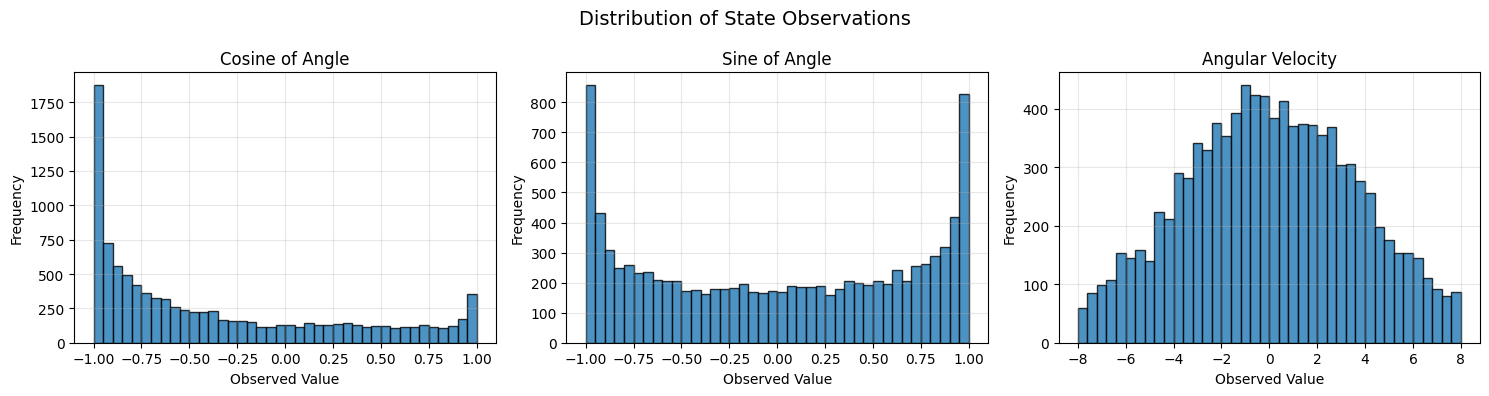

In [6]:
state_names = [
    "Cosine of Angle",
    "Sine of Angle",
    "Angular Velocity"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for index, axis in enumerate(axes):
    axis.hist(
        collected_states[:, index],
        bins=40,
        alpha=0.8,
        edgecolor="black"
    )

    axis.set_title(state_names[index])
    axis.set_xlabel("Observed Value")
    axis.set_ylabel("Frequency")
    axis.grid(alpha=0.3)

plt.suptitle(
    "Distribution of State Observations",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Interpretation of State Observation Distributions

The cosine and sine observations remained within their expected range of -1 to 1. The cosine distribution contains a large concentration near -1, indicating that the randomly controlled pendulum frequently remained close to the downward position.

The sine values were spread across the complete range, with higher frequencies near both -1 and 1. This shows that the random torque actions caused the pendulum to experience many different angular positions.

Angular velocity ranged from approximately -8 to 8, with most observations concentrated near the centre. Extremely high positive or negative rotational speeds occurred less frequently.

Overall, the random agent explored the complete observation space, although the state distribution was not uniform.

### Distribution of Random Actions and Rewards

The distributions of the randomly selected torque values and the resulting rewards were examined.

Since the actions were sampled randomly from the continuous action space, torque values across the range of -2 to 2 are expected. The reward distribution provides a baseline indication of the performance achieved without learning.

For the Pendulum environment, rewards are negative. Values closer to zero represent better control of the pendulum.

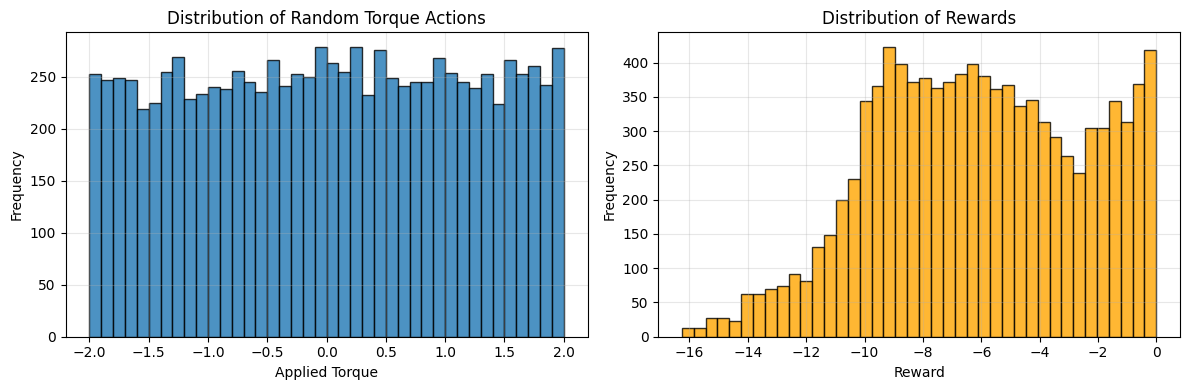

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    collected_actions,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Distribution of Random Torque Actions")
axes[0].set_xlabel("Applied Torque")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

axes[1].hist(
    collected_rewards,
    bins=40,
    edgecolor="black",
    alpha=0.8,
    color="orange"
)

axes[1].set_title("Distribution of Rewards")
axes[1].set_xlabel("Reward")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Random Actions and Rewards

The random torque actions were distributed relatively evenly between -2.0 and 2.0. This confirms that both clockwise and anticlockwise torques were explored without a strong directional bias.

All rewards were negative, ranging from approximately -16 to values close to zero. In the Pendulum environment, the agent is penalised for an incorrect angle, excessive angular velocity and large torque values. Therefore, rewards closer to zero represent better control.

The wide reward distribution shows that random actions produced both poor and occasionally favourable pendulum states, but did not provide consistently effective control.

### Initial Comparison of Gravity Conditions

The Pendulum environment was explored under the four gravity conditions required by the assignment:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

A random agent was evaluated under each condition to examine how gravity affects the environment before DQN training.

The same number of episodes and random seed were used for every gravity condition to make the comparison fair. These results represent untrained baseline performance and will later be compared with the trained DQN agents.

In [8]:
gravity_settings = {
    "Default": 10.0,
    "Free-fall": 0.0,
    "Anti-gravity": -10.0,
    "Supergravity": 15.0
}

episodes_per_gravity = 30
gravity_baseline_returns = {}

for gravity_name, gravity_value in gravity_settings.items():
    env = gym.make("Pendulum-v1")
    env.unwrapped.g = gravity_value

    env.seed(42)
    env.action_space.seed(42)

    condition_returns = []

    for episode in range(episodes_per_gravity):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = env.action_space.sample()

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

        condition_returns.append(total_reward)

    gravity_baseline_returns[gravity_name] = np.array(
        condition_returns
    )

    env.close()

    print(
        gravity_name,
        "- Mean:",
        np.mean(condition_returns),
        "- Standard deviation:",
        np.std(condition_returns)
    )

c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


Default - Mean: -1189.63307601102 - Standard deviation: 231.64725307533595
Free-fall - Mean: -748.6178031504127 - Standard deviation: 184.61422238394752
Anti-gravity - Mean: -602.1183430727535 - Standard deviation: 396.9365950877032
Supergravity - Mean: -1386.837203404409 - Standard deviation: 124.56566538166022


### Random-Agent Performance Across Gravity Conditions

The random agent produced the following mean episodic returns:

| Gravity condition | Mean return | Standard deviation |
|---|---:|---:|
| Default | -1189.63 | 231.65 |
| Free-fall | -748.62 | 184.61 |
| Anti-gravity | -602.12 | 396.94 |
| Supergravity | -1386.84 | 124.57 |

Anti-gravity produced the best random-agent mean return because -602.12 was closest to zero. However, it also had the highest standard deviation, indicating inconsistent performance.

Supergravity produced the poorest mean return of -1386.84. Its stronger gravitational force made random torque actions less capable of maintaining the pendulum near the upright position.

These results demonstrate that gravity substantially affects the difficulty and variability of the control task.

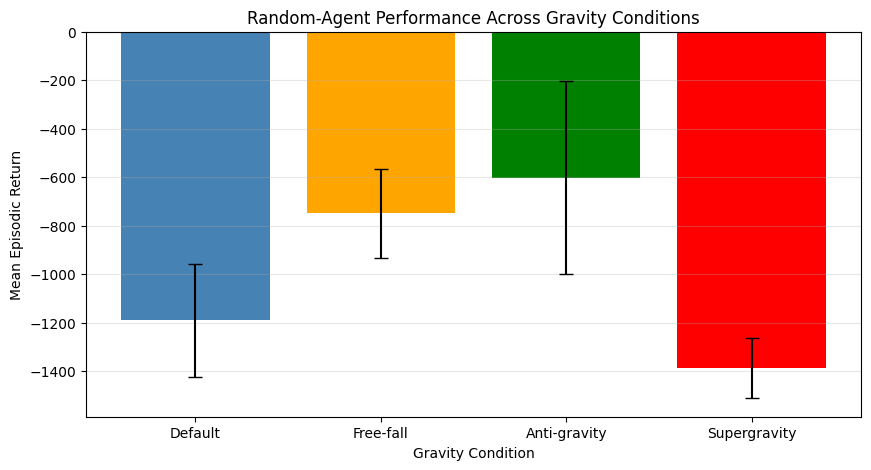

In [9]:
gravity_names = list(gravity_baseline_returns.keys())

mean_returns = [
    gravity_baseline_returns[name].mean()
    for name in gravity_names
]

return_standard_deviations = [
    gravity_baseline_returns[name].std()
    for name in gravity_names
]

plt.figure(figsize=(10, 5))

plt.bar(
    gravity_names,
    mean_returns,
    yerr=return_standard_deviations,
    capsize=5,
    color=["steelblue", "orange", "green", "red"]
)

plt.title("Random-Agent Performance Across Gravity Conditions")
plt.xlabel("Gravity Condition")
plt.ylabel("Mean Episodic Return")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation of Gravity Baselines

The random agent achieved different levels of performance under the four gravity conditions.

Free-fall produced the highest mean episodic return, with an average of approximately **-760**. Without gravitational force pulling the pendulum downwards, the random agent was more likely to remain in comparatively favourable positions.

Anti-gravity produced the second-highest mean return of approximately **-850**. However, it also had the largest standard deviation, indicating that its performance varied considerably between episodes.

The default-gravity condition produced a lower mean return of approximately **-1350**, while supergravity produced the lowest mean return of approximately **-1480**. The stronger gravitational force in supergravity makes it more difficult for randomly selected torque actions to move and maintain the pendulum near the upright position.

The overlapping error bars show that random-agent performance varies between episodes. Therefore, multiple evaluation episodes should also be used when comparing trained DQN agents.

Each trained agent should be compared against the random baseline from the same gravity condition because the four environments have different levels of difficulty.

In [10]:
# EDA: Verify Custom Gravity Testing Compatibility
gravity_test_values = [10.0, 0.0, -10.0, 15.0]

print("Testing dynamic gravity configuration:")
for g in gravity_test_values:
    test_env = gym.make("Pendulum-v1")
    test_env.unwrapped.g = g
    test_env.reset()
    
    # Execute 1 dummy step
    _, reward, _, _ = test_env.step(test_env.action_space.sample())
    print(f"  Gravity set to {g:5.1f} | Sample Step Reward: {reward:.4f}")
    test_env.close()

Testing dynamic gravity configuration:
  Gravity set to  10.0 | Sample Step Reward: -6.9256
  Gravity set to   0.0 | Sample Step Reward: -5.2156
  Gravity set to -10.0 | Sample Step Reward: -0.2479
  Gravity set to  15.0 | Sample Step Reward: -1.3001


### Gravity Configuration Verification

Different sample rewards were obtained when the gravitational strength was changed. This confirms that the custom gravity value was successfully applied to the environment.

The sample rewards should not be used as the final comparison because they represent only one transition. The full episodic evaluation is used later to compare performance reliably.

## Data Preprocessing

The exploratory analysis found no missing or infinite values in the environment observations, actions or rewards. Therefore, no interaction data needs to be removed or imputed.

However, two preprocessing steps are required before DQN can be applied:

1. Discretise the continuous torque action space.
2. Scale the state observations to a similar numerical range.

These transformations will make the Pendulum environment suitable for training with a Deep Q-Network.

# Observation Normalization Function

In [11]:
import numpy as np

# Preprocessing: State Observation Scaler
def normalize_state(state):
    """
    Normalize Pendulum state to approximately [-1, 1].

    State format:
        state[0] = cos(theta)  -> already in [-1, 1]
        state[1] = sin(theta)  -> already in [-1, 1]
        state[2] = theta_dot   -> expected in [-8, 8]

    Returns:
        Normalized state as float32.
    """
    state = np.asarray(state, dtype=np.float32).copy()

    # Scale angular velocity
    state[2] = np.clip(state[2] / 8.0, -1.0, 1.0)

    return state

sample_raw_state = np.array([0.5, -0.5, 6.0], dtype=np.float32)
sample_norm_state = normalize_state(sample_raw_state)

print("Raw State Sample        :", sample_raw_state)
print("Normalized State Sample :", sample_norm_state)

Raw State Sample        : [ 0.5 -0.5  6. ]
Normalized State Sample : [ 0.5  -0.5   0.75]


### State Normalisation Result

The cosine and sine observations were already bounded between -1 and 1. Angular velocity originally ranged from -8 to 8 and was divided by 8 to scale it to approximately -1 to 1.

For example, the angular velocity value of 6.0 was converted to 0.75. After processing the complete dataset, all three state variables were within the range of approximately -1 to 1.

This gives the neural network inputs with a consistent scale and prevents angular velocity from having a disproportionately large numerical magnitude.

### Action-Space Discretisation

Pendulum has a continuous torque range from −2 to 2, while DQN requires discrete actions. The common configuration divides this interval into **40 evenly spaced torque actions**.

The same 40-action mapping is used for the baseline, Kayden's candidate and the other group member's candidate during model selection. Although an even number of actions does not contain exactly zero torque, it provides two small actions close to zero and maintains the agreed controlled configuration.


In [12]:
action_env = gym.make("Pendulum-v1")
ACTION_LOW = float(action_env.action_space.low[0])
ACTION_HIGH = float(action_env.action_space.high[0])
action_env.close()


def create_action_values(num_actions):
    return np.linspace(
        ACTION_LOW,
        ACTION_HIGH,
        int(num_actions),
        dtype=np.float32
    )


def action_index_to_torque(action_index, action_values):
    action_index = int(action_index)

    if not 0 <= action_index < len(action_values):
        raise ValueError("Action index is outside the discretised action space.")

    return np.array(
        [action_values[action_index]],
        dtype=np.float32
    )


common_action_values = create_action_values(40)

print("Number of discrete actions:", len(common_action_values))
print("Minimum torque:", common_action_values.min())
print("Maximum torque:", common_action_values.max())
print("Two actions closest to zero:", common_action_values[19:21])


Number of discrete actions: 40
Minimum torque: -2.0
Maximum torque: 2.0
Two actions closest to zero: [-0.05128205  0.05128205]


### Action Discretisation Result

The continuous torque range from -2.0 to 2.0 was divided into 40 discrete actions. The smallest torque was -2.0 and the largest was 2.0.

The two actions closest to zero were approximately -0.0513 and 0.0513. An even number of actions was used, so an exact zero-torque action was not included.

This discretisation allows C51 to select torque actions using a discrete action index while still providing a sufficiently detailed range of control values.

### State Casting and Scaling

The state contains three observations with different numerical ranges:

- Cosine of angle: −1 to 1
- Sine of angle: −1 to 1
- Angular velocity: −8 to 8

Angular velocity is divided by 8 so that all three features are approximately within −1 to 1. The states are also converted to `float32`, which is suitable for TensorFlow training.


In [13]:
state_scale = np.array(
    [1.0, 1.0, 8.0],
    dtype=np.float32
)


def preprocess_state(state):
    state = np.asarray(state, dtype=np.float32)
    scaled_state = state / state_scale
    return np.clip(scaled_state, -1.0, 1.0)


In [14]:
env = gym.make("Pendulum-v1")
original_state = env.reset()
original_state = original_state[0] if isinstance(original_state, tuple) else original_state
processed_state = preprocess_state(original_state)
env.close()

print("Original state:", original_state)
print("Processed state:", processed_state)
print("Processed datatype:", processed_state.dtype)


Original state: [ 0.9737531  -0.22760682  0.11116602]
Processed state: [ 0.9737531  -0.22760682  0.01389575]
Processed datatype: float32


In [15]:
processed_collected_states = np.array([
    preprocess_state(state)
    for state in collected_states
])

print("Original minimum values:", collected_states.min(axis=0))
print("Original maximum values:", collected_states.max(axis=0))
print("Processed minimum values:", processed_collected_states.min(axis=0))
print("Processed maximum values:", processed_collected_states.max(axis=0))


Original minimum values: [-0.9999999  -0.99999976 -8.        ]
Original maximum values: [0.99999994 0.99999976 8.        ]
Processed minimum values: [-0.9999999  -0.99999976 -1.        ]
Processed maximum values: [0.99999994 0.99999976 1.        ]


### Verification of State Preprocessing

Before preprocessing, cosine and sine were already within −1 to 1, while angular velocity ranged from −8 to 8. After scaling, all three observations are within approximately −1 to 1. Small differences from the exact limits are caused by floating-point precision and do not require correction.


## Modelling Workflow

1. Lock C51 as the common model architecture.
2. Train an untuned C51 benchmark under all four gravities using one common configuration.
3. Evaluate the untuned agents using validation seeds 1000–1019.
4. Train gravity-specific candidate configurations.
5. Select the best configuration separately for each gravity using mean validation return.
6. Evaluate the selected agents once using unseen seeds 2000–2029.
7. Compare untuned C51 against gravity-tuned C51.

The architecture remains unchanged throughout. Only environment-specific hyperparameters and the learned weights may differ.


## C51 Distributional DQN

A standard DQN predicts one scalar Q-value for each action. C51 instead predicts a probability distribution across 51 fixed return values, known as atoms, for every discrete torque action.

The expected action value is:

$$
Q(s,a)=\sum_{i=1}^{51}p_i(s,a)z_i
$$

where $p_i(s,a)$ is the predicted probability of atom $z_i$. The greedy action is selected using the highest expected return. Training uses a projected distributional Bellman target and categorical cross-entropy loss.


## Common Configuration and Weight Folders


In [16]:
COMMON_CONFIG = {
    "episodes": 150,
    "gamma": 0.99,
    "epsilon": 1.0,
    "epsilon_min": 0.01,
    "epsilon_decay": 0.98,
    "hidden_size": 64,
    "num_actions": 40,
    "batch_size": 32,
    "replay_memory_size": 10000,
    "min_replay_memory": 1000,
    "target_update_every": 1,
    "learning_rate": 0.001,
    "action_range": (-2.0, 2.0)
}

C51_SPECIFIC_CONFIG = {
    "num_atoms": 51,
    "v_min": -2500.0,
    "v_max": 0.0
}

GRAVITY_CONFIGS = {
    "g=-10": {**COMMON_CONFIG, "gravity": -10.0},
    "g=0":   {**COMMON_CONFIG, "gravity": 0.0},
    "g=10":  {**COMMON_CONFIG, "gravity": 10.0},
    "g=15":  {**COMMON_CONFIG, "gravity": 15.0}
}

GRAVITY_LABELS = {
    "g=-10": "Anti-gravity",
    "g=0": "Free-fall",
    "g=10": "Default",
    "g=15": "Supergravity"
}

GRAVITY_COLOURS = {
    "g=-10": "tab:green",
    "g=0": "tab:orange",
    "g=10": "tab:blue",
    "g=15": "tab:red"
}

# Workload split. Change only this line when sharing the notebook.
TUNING_SCOPE = "all"  # Choose: "kayden", "partner", or "all"

OWNER_GRAVITIES = {
    "kayden": ["g=10", "g=15"],
    "partner": ["g=-10", "g=0"],
    "all": list(GRAVITY_CONFIGS.keys())
}

if TUNING_SCOPE not in OWNER_GRAVITIES:
    raise ValueError("TUNING_SCOPE must be 'kayden', 'partner', or 'all'.")

GRAVITIES_TO_RUN = OWNER_GRAVITIES[TUNING_SCOPE]

# Every weight file is stored below this one folder.
WEIGHTS_DIR = Path("PtBkaydenC51_weights")
UNTUNED_WEIGHTS_DIR = WEIGHTS_DIR / "untuned"
TUNING_WEIGHTS_DIR = WEIGHTS_DIR / "tuning_trials"
FINAL_WEIGHTS_DIR = WEIGHTS_DIR / "final_selected"

for folder in [UNTUNED_WEIGHTS_DIR, TUNING_WEIGHTS_DIR, FINAL_WEIGHTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Weight directory:", WEIGHTS_DIR.resolve())
print("Tuning scope:", TUNING_SCOPE)
print("Gravities:", [GRAVITY_LABELS[g] for g in GRAVITIES_TO_RUN])
print("\nCommon configuration")
for key, value in COMMON_CONFIG.items():
    print(f"{key:<24}: {value}")

print("\nC51-specific configuration")
for key, value in C51_SPECIFIC_CONFIG.items():
    print(f"{key:<24}: {value}")


Weight directory: C:\Users\kayde\OneDrive\DELE\DELECA2\deleca2\PtBkaydenC51_weights
Tuning scope: all
Gravities: ['Anti-gravity', 'Free-fall', 'Default', 'Supergravity']

Common configuration
episodes                : 150
gamma                   : 0.99
epsilon                 : 1.0
epsilon_min             : 0.01
epsilon_decay           : 0.98
hidden_size             : 64
num_actions             : 40
batch_size              : 32
replay_memory_size      : 10000
min_replay_memory       : 1000
target_update_every     : 1
learning_rate           : 0.001
action_range            : (-2.0, 2.0)

C51-specific configuration
num_atoms               : 51
v_min                   : -2500.0
v_max                   : 0.0


## Environment and Action Helpers


In [17]:
def create_env(gravity):
    return gym.make(
        "Pendulum-v1",
        g=float(gravity),
        new_step_api=True
    )


def reset_environment(env, seed=None):
    result = env.reset(seed=seed) if seed is not None else env.reset()
    state = result[0] if isinstance(result, tuple) else result
    return preprocess_state(state)


def step_environment(env, action):
    result = env.step(action)

    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
        done = terminated or truncated
    else:
        next_state, reward, done, info = result

    return preprocess_state(next_state), float(reward), bool(done), info


def build_model_config(gravity_name, overrides=None):
    config = GRAVITY_CONFIGS[gravity_name].copy()
    config.update(C51_SPECIFIC_CONFIG)

    if overrides:
        config.update(overrides)

    return config


def safe_name(text):
    return (
        str(text)
        .lower()
        .replace("=", "")
        .replace("-", "neg")
        .replace(" ", "_")
        .replace("/", "_")
    )


## C51 Agent


In [18]:
class C51DQNAgent:
    def __init__(self, state_dim, action_dim, config):
        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)
        self.gamma = float(config["gamma"])
        self.learning_rate = float(config["learning_rate"])
        self.hidden_size = int(config["hidden_size"])

        self.epsilon = float(config["epsilon"])
        self.epsilon_min = float(config["epsilon_min"])
        self.epsilon_decay = float(config["epsilon_decay"])

        self.batch_size = int(config["batch_size"])
        self.min_replay_memory = int(config["min_replay_memory"])
        self.memory = deque(maxlen=int(config["replay_memory_size"]))

        self.num_atoms = int(config["num_atoms"])
        self.v_min = float(config["v_min"])
        self.v_max = float(config["v_max"])

        self.support = np.linspace(
            self.v_min,
            self.v_max,
            self.num_atoms,
            dtype=np.float32
        )
        self.delta_z = (
            self.v_max - self.v_min
        ) / (self.num_atoms - 1)

        self.optimizer = tf.keras.optimizers.Adam(
            learning_rate=self.learning_rate
        )

        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_network()

    def _build_model(self):
        inputs = layers.Input(shape=(self.state_dim,))
        features = layers.Dense(
            self.hidden_size,
            activation="relu"
        )(inputs)
        features = layers.Dense(
            self.hidden_size,
            activation="relu"
        )(features)

        logits = layers.Dense(
            self.action_dim * self.num_atoms
        )(features)
        logits = layers.Reshape(
            (self.action_dim, self.num_atoms)
        )(logits)

        probabilities = layers.Softmax(axis=-1)(logits)

        return tf.keras.Model(
            inputs=inputs,
            outputs=probabilities
        )

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def _expected_q_values(self, distributions):
        support_tensor = tf.convert_to_tensor(
            self.support,
            dtype=tf.float32
        )
        return tf.reduce_sum(
            distributions * support_tensor,
            axis=-1
        )

    def act(self, state, explore=True):
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        state_tensor = tf.convert_to_tensor(
            state[None, :],
            dtype=tf.float32
        )
        distributions = self.model(state_tensor, training=False)
        q_values = self._expected_q_values(distributions)
        return int(tf.argmax(q_values[0]).numpy())

    def policy_metrics(self, state):
        state_tensor = tf.convert_to_tensor(
            state[None, :],
            dtype=tf.float32
        )
        distributions = self.model(state_tensor, training=False)
        q_values = self._expected_q_values(distributions).numpy()[0]
        greedy_action = int(np.argmax(q_values))

        selected_distribution = distributions.numpy()[0, greedy_action]
        entropy = -np.sum(
            selected_distribution
            * np.log(np.clip(selected_distribution, 1e-8, 1.0))
        )

        return float(np.max(q_values)), float(entropy)

    def _project_distribution(
        self,
        rewards,
        dones,
        next_distributions
    ):
        projected = np.zeros(
            (self.batch_size, self.num_atoms),
            dtype=np.float32
        )
        batch_indices = np.arange(self.batch_size)

        for atom_index in range(self.num_atoms):
            target_atoms = (
                rewards
                + (1.0 - dones)
                * self.gamma
                * self.support[atom_index]
            )
            target_atoms = np.clip(
                target_atoms,
                self.v_min,
                self.v_max
            )

            positions = (
                target_atoms - self.v_min
            ) / self.delta_z
            lower = np.floor(positions).astype(np.int32)
            upper = np.ceil(positions).astype(np.int32)

            probabilities = next_distributions[:, atom_index]
            equal_mask = lower == upper
            unequal_mask = ~equal_mask

            projected[
                batch_indices[equal_mask],
                lower[equal_mask]
            ] += probabilities[equal_mask]

            projected[
                batch_indices[unequal_mask],
                lower[unequal_mask]
            ] += (
                probabilities[unequal_mask]
                * (upper[unequal_mask] - positions[unequal_mask])
            )

            projected[
                batch_indices[unequal_mask],
                upper[unequal_mask]
            ] += (
                probabilities[unequal_mask]
                * (positions[unequal_mask] - lower[unequal_mask])
            )

        projected /= np.maximum(
            projected.sum(axis=1, keepdims=True),
            1e-8
        )
        return projected

    def replay(self):
        if len(self.memory) < self.min_replay_memory:
            return None

        minibatch = random.sample(self.memory, self.batch_size)

        states = np.asarray([item[0] for item in minibatch], dtype=np.float32)
        actions = np.asarray([item[1] for item in minibatch], dtype=np.int32)
        rewards = np.asarray([item[2] for item in minibatch], dtype=np.float32)
        next_states = np.asarray([item[3] for item in minibatch], dtype=np.float32)
        dones = np.asarray([item[4] for item in minibatch], dtype=np.float32)

        # Standard C51 target: target network selects and evaluates next actions.
        target_next_distributions = self.target_model(
            next_states,
            training=False
        )
        target_next_q = self._expected_q_values(
            target_next_distributions
        ).numpy()
        best_next_actions = np.argmax(target_next_q, axis=1)

        selected_next_distributions = (
            target_next_distributions.numpy()[
                np.arange(self.batch_size),
                best_next_actions
            ]
        )

        projected_targets = self._project_distribution(
            rewards,
            dones,
            selected_next_distributions
        )

        states_tensor = tf.convert_to_tensor(states, dtype=tf.float32)
        actions_tensor = tf.convert_to_tensor(actions, dtype=tf.int32)
        targets_tensor = tf.convert_to_tensor(
            projected_targets,
            dtype=tf.float32
        )

        with tf.GradientTape() as tape:
            all_distributions = self.model(
                states_tensor,
                training=True
            )
            chosen_distributions = tf.gather(
                all_distributions,
                actions_tensor,
                batch_dims=1
            )

            chosen_distributions = tf.clip_by_value(
                chosen_distributions,
                1e-8,
                1.0
            )

            loss = -tf.reduce_mean(
                tf.reduce_sum(
                    targets_tensor
                    * tf.math.log(chosen_distributions),
                    axis=1
                )
            )

        gradients = tape.gradient(
            loss,
            self.model.trainable_variables
        )
        self.optimizer.apply_gradients(
            zip(gradients, self.model.trainable_variables)
        )

        return float(loss.numpy())


## Shared Training Function

The same training function is used for the untuned benchmark and every tuning trial. It records episode return, 10-episode moving-average return, loss, expected Q-value, episode length, epsilon, upright percentage and distribution entropy.

The best checkpoint is selected using the highest 10-episode moving-average training return. Checkpoints are written into the requested subfolder inside `c51_weights/`.


In [19]:
def train_c51(
    gravity_name,
    config,
    run_label,
    checkpoint_group,
    seed=42
):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    env = create_env(config["gravity"])
    action_values = create_action_values(config["num_actions"])
    agent = C51DQNAgent(
        state_dim=env.observation_space.shape[0],
        action_dim=config["num_actions"],
        config=config
    )

    history = {
        "returns": [],
        "moving_avg_returns": [],
        "episode_lengths": [],
        "avg_max_q": [],
        "losses": [],
        "epsilons": [],
        "upright_percentages": [],
        "distribution_entropies": []
    }

    checkpoint_folder = WEIGHTS_DIR / checkpoint_group
    checkpoint_folder.mkdir(parents=True, exist_ok=True)
    checkpoint_path = checkpoint_folder / (
        f"{safe_name(gravity_name)}_{safe_name(run_label)}.weights.h5"
    )

    best_moving_return = -np.inf

    print("\n" + "=" * 72)
    print(f"Training {run_label} | {GRAVITY_LABELS[gravity_name]} ({gravity_name})")
    print("=" * 72)

    for episode in range(1, config["episodes"] + 1):
        state = reset_environment(env, seed=seed + episode)
        done = False
        total_reward = 0.0
        step_count = 0
        upright_steps = 0
        step_max_q = []
        step_losses = []
        step_entropies = []

        while not done:
            max_q, entropy = agent.policy_metrics(state)
            step_max_q.append(max_q)

            if np.isfinite(entropy):
                step_entropies.append(entropy)

            if state[0] > 0.95:
                upright_steps += 1

            action_index = agent.act(state, explore=True)
            torque = action_index_to_torque(action_index, action_values)
            next_state, reward, done, _ = step_environment(env, torque)

            agent.remember(state, action_index, reward, next_state, done)
            loss = agent.replay()

            if loss is not None:
                step_losses.append(loss)

            state = next_state
            total_reward += reward
            step_count += 1

        agent.epsilon = max(
            agent.epsilon_min,
            agent.epsilon * agent.epsilon_decay
        )

        if episode % config["target_update_every"] == 0:
            agent.update_target_network()

        history["returns"].append(total_reward)
        history["moving_avg_returns"].append(
            float(np.mean(history["returns"][-10:]))
        )
        history["episode_lengths"].append(step_count)
        history["avg_max_q"].append(float(np.mean(step_max_q)))
        history["losses"].append(
            float(np.mean(step_losses)) if step_losses else np.nan
        )
        history["epsilons"].append(agent.epsilon)
        history["upright_percentages"].append(
            100.0 * upright_steps / step_count if step_count else 0.0
        )
        history["distribution_entropies"].append(
            float(np.mean(step_entropies)) if step_entropies else np.nan
        )

        latest_average = history["moving_avg_returns"][-1]

        if episode >= 10 and latest_average > best_moving_return:
            best_moving_return = latest_average
            agent.model.save_weights(str(checkpoint_path))

        if episode == 1 or episode % 10 == 0:
            print(
                f"Episode {episode:3d}/{config['episodes']} | "
                f"Return: {total_reward:8.2f} | "
                f"10-Ep Avg: {latest_average:8.2f} | "
                f"Loss: {history['losses'][-1]:7.4f} | "
                f"Epsilon: {agent.epsilon:.3f}"
            )

    env.close()
    agent.model.load_weights(str(checkpoint_path))
    agent.update_target_network()

    return {
        "agent": agent,
        "history": history,
        "config": config.copy(),
        "action_values": action_values,
        "checkpoint_path": str(checkpoint_path),
        "run_label": run_label,
        "gravity_name": gravity_name,
        "best_moving_return": float(best_moving_return)
    }


# Part 1: Untuned C51 Benchmark


The benchmark uses the same `COMMON_CONFIG` and C51 support for every gravity. These agents provide the reference performance before environment-specific tuning.


In [20]:
RUN_UNTUNED_TRAINING = True
untuned_results = {}

if RUN_UNTUNED_TRAINING:
    for gravity_name in GRAVITIES_TO_RUN:
        untuned_results[gravity_name] = train_c51(
            gravity_name=gravity_name,
            config=build_model_config(gravity_name),
            run_label="Untuned_C51",
            checkpoint_group="untuned",
            seed=42
        )
else:
    print("Set RUN_UNTUNED_TRAINING = True to train the benchmark agents.")


c:\Users\kayde\anaconda3\envs\st1504_rl\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)



Training Untuned_C51 | Anti-gravity (g=-10)
Episode   1/150 | Return:   -88.83 | 10-Ep Avg:   -88.83 | Loss:     nan | Epsilon: 0.980
Episode  10/150 | Return:  -328.77 | 10-Ep Avg:  -623.92 | Loss:  3.5713 | Epsilon: 0.817
Episode  20/150 | Return:   -36.22 | 10-Ep Avg:  -404.73 | Loss:  2.0003 | Epsilon: 0.668
Episode  30/150 | Return:  -386.87 | 10-Ep Avg:  -545.71 | Loss:  1.1170 | Epsilon: 0.545
Episode  40/150 | Return:  -416.16 | 10-Ep Avg:  -229.49 | Loss:  0.6894 | Epsilon: 0.446
Episode  50/150 | Return:   -44.78 | 10-Ep Avg:  -106.16 | Loss:  0.5465 | Epsilon: 0.364
Episode  60/150 | Return:  -202.23 | 10-Ep Avg:  -148.11 | Loss:  0.3815 | Epsilon: 0.298
Episode  70/150 | Return:  -227.18 | 10-Ep Avg:  -137.56 | Loss:  0.3178 | Epsilon: 0.243
Episode  80/150 | Return:   -92.49 | 10-Ep Avg:  -120.39 | Loss:  0.2480 | Epsilon: 0.199
Episode  90/150 | Return:   -97.95 | 10-Ep Avg:   -87.33 | Loss:  0.1860 | Epsilon: 0.162
Episode 100/150 | Return:  -197.62 | 10-Ep Avg:  -110.1

## Untuned Reward Graphs


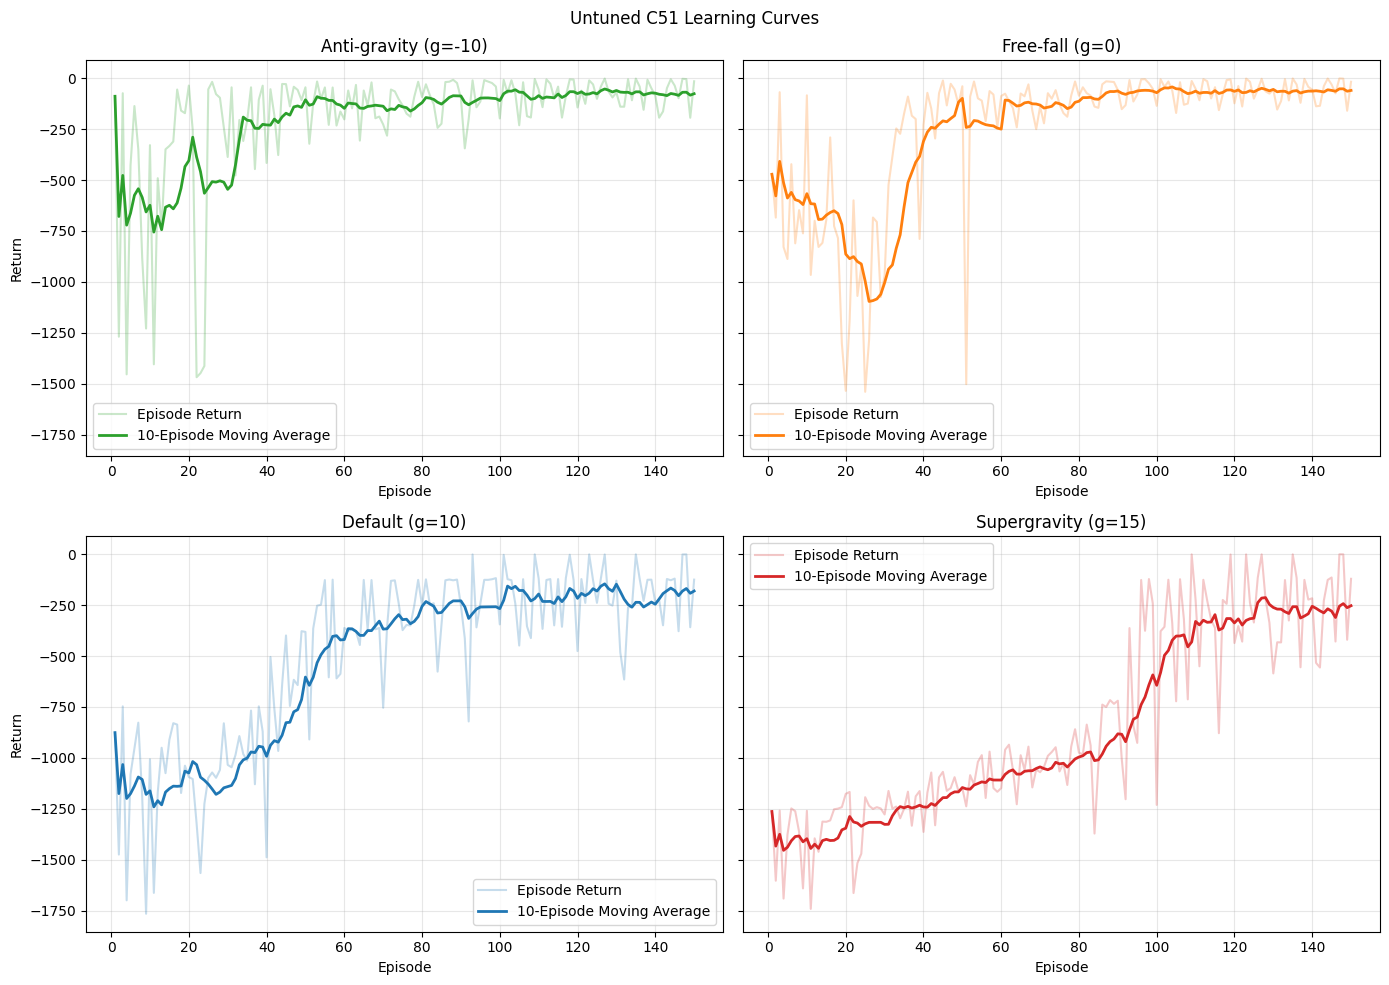

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for axis_index, axis in enumerate(axes.flat):
    if axis_index >= len(GRAVITIES_TO_RUN):
        axis.axis("off")
        continue

    gravity_name = GRAVITIES_TO_RUN[axis_index]
    history = untuned_results[gravity_name]["history"]
    episodes = np.arange(1, len(history["returns"]) + 1)

    axis.plot(
        episodes,
        history["returns"],
        alpha=0.25,
        color=GRAVITY_COLOURS[gravity_name],
        label="Episode Return"
    )
    axis.plot(
        episodes,
        history["moving_avg_returns"],
        linewidth=2,
        color=GRAVITY_COLOURS[gravity_name],
        label="10-Episode Moving Average"
    )
    axis.set_title(f"{GRAVITY_LABELS[gravity_name]} ({gravity_name})")
    axis.set_xlabel("Episode")
    axis.grid(alpha=0.3)
    axis.legend()

axes[0, 0].set_ylabel("Return")
axes[1, 0].set_ylabel("Return")
plt.suptitle("Untuned C51 Learning Curves")
plt.tight_layout()
plt.show()


### Untuned C51 Learning-Curve Interpretation

The untuned C51 agents improved under all four gravity conditions during the 150 training episodes.

Anti-gravity improved quickly, with its 10-episode moving-average return increasing from below -600 during early training to -76.31 by Episode 150.

Free-fall experienced unstable performance during approximately the first 40 episodes but subsequently improved rapidly. Its final 10-episode moving-average return was -60.10, which was the best among the four gravities.

Default gravity improved more gradually from below -1000 to a final moving average of -180.78.

Supergravity was the most difficult condition. Its moving-average return remained below -1000 for much of training before improving sharply after approximately Episode 90. It reached -252.95 by Episode 150.

Overall, the curves show that C51 learned useful control policies under every gravity, although stronger gravity required more episodes and produced poorer final returns.

## Untuned Loss Graph


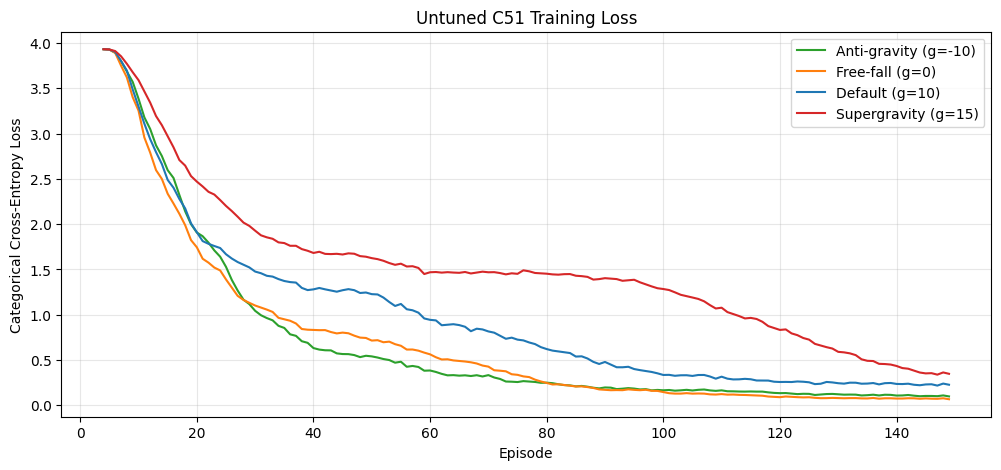

In [22]:
plt.figure(figsize=(12, 5))

for gravity_name, result in untuned_results.items():
    plt.plot(
        result["history"]["losses"],
        color=GRAVITY_COLOURS[gravity_name],
        label=f"{GRAVITY_LABELS[gravity_name]} ({gravity_name})"
    )

plt.xlabel("Episode")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.title("Untuned C51 Training Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Greedy Evaluation Helper


In [ ]:
def evaluate_trained_result(training_result, evaluation_seeds):
    agent = training_result["agent"]
    config = training_result["config"]
    action_values = training_result["action_values"]
    env = create_env(config["gravity"])
    returns = []

    for seed in evaluation_seeds:
        state = reset_environment(env, seed=int(seed))
        done = False
        total_reward = 0.0

        while not done:
            action_index = agent.act(state, explore=False)
            torque = action_index_to_torque(action_index, action_values)
            state, reward, done, _ = step_environment(env, torque)
            total_reward += reward

        returns.append(total_reward)

    env.close()
    return np.asarray(returns, dtype=np.float32)


def return_statistics(returns):
    return {
        "mean": float(np.mean(returns)),
        "median": float(np.median(returns)),
        "std": float(np.std(returns)),
        "best": float(np.max(returns)),
        "worst": float(np.min(returns))
    }


VALIDATION_SEEDS = np.arange(1000, 1020)
FINAL_TEST_SEEDS = np.arange(2000, 2030)

untuned_validation_returns = {
    gravity_name: evaluate_trained_result(result, VALIDATION_SEEDS)
    for gravity_name, result in untuned_results.items()
}

print("Untuned C51 validation results")
print("-" * 94)
print(f"{'Gravity':<16}{'Mean':>12}{'Median':>12}{'Std Dev':>12}{'Best':>12}{'Worst':>12}")

for gravity_name, returns in untuned_validation_returns.items():
    stats = return_statistics(returns)
    print(
        f"{GRAVITY_LABELS[gravity_name]:<16}"
        f"{stats['mean']:>12.2f}{stats['median']:>12.2f}"
        f"{stats['std']:>12.2f}{stats['best']:>12.2f}{stats['worst']:>12.2f}"
    )


Untuned C51 validation results
----------------------------------------------------------------------------------------------
Gravity                 Mean      Median     Std Dev        Best       Worst
Anti-gravity          -63.11      -56.46       52.97       -0.42     -174.00
Free-fall             -46.98      -38.83       41.36       -0.46     -124.86
Default              -165.56     -127.30       93.11       -2.91     -358.74
Supergravity         -239.28     -224.88      141.22       -1.26     -466.95


### Untuned C51 Validation Results

The untuned agents were evaluated greedily using 20 validation seeds without exploration or further learning.

| Gravity | Mean | Median | Standard deviation | Best | Worst |
|---|---:|---:|---:|---:|---:|
| Anti-gravity | -63.11 | -56.46 | 52.97 | -0.42 | -174.00 |
| Free-fall | -46.98 | -38.83 | 41.36 | -0.46 | -124.86 |
| Default | -165.56 | -127.30 | 93.11 | -2.91 | -358.74 |
| Supergravity | -239.28 | -224.88 | 141.22 | -1.26 | -466.95 |

Free-fall achieved the best mean return and lowest standard deviation, indicating the strongest and most consistent untuned performance.

Supergravity produced the poorest mean return and highest variability. This confirms that stronger gravity created the most difficult control condition.

Although all four agents occasionally achieved returns close to zero, their worst returns show that performance still depended on the initial state.

# Part 2: Gravity-Specific Hyperparameter Tuning


Each gravity begins with the untuned benchmark and two additional candidate configurations. The candidates retain the same C51 architecture but adjust selected hyperparameters that can influence learning stability, exploration, torque precision and return-distribution coverage.

To divide the workload, set `TUNING_SCOPE` to `"kayden"` or `"partner"`. Use `"all"` when producing the final consolidated notebook.


In [ ]:
GRAVITIES_TO_TUNE = GRAVITIES_TO_RUN

TUNING_CANDIDATES = {
    "g=-10": {
        "Stable_Learning": {
            "learning_rate": 0.0005,
            "epsilon_decay": 0.985
        },
        "Fine_Actions": {
            "learning_rate": 0.0005,
            "epsilon_decay": 0.985,
            "num_actions": 61
        }
    },
    "g=0": {
        "Compact_Support": {
            "learning_rate": 0.0005,
            "v_min": -1500.0
        },
        "Fine_Actions": {
            "learning_rate": 0.0005,
            "num_actions": 61,
            "v_min": -1500.0
        }
    },
    "g=10": {
        "Stable_Learning": {
            "learning_rate": 0.0005,
            "epsilon_decay": 0.985
        },
        "Fine_Actions": {
            "learning_rate": 0.0005,
            "epsilon_decay": 0.985,
            "num_actions": 61
        }
    },
    "g=15": {
        "Wide_Support": {
            "learning_rate": 0.0005,
            "epsilon_decay": 0.985,
            "v_min": -3500.0
        },
        "Fine_Actions": {
            "learning_rate": 0.0005,
            "epsilon_decay": 0.985,
            "num_actions": 61,
            "v_min": -3500.0
        }
    }
}

print("Tuning scope:", TUNING_SCOPE)
print("Gravities:", [GRAVITY_LABELS[g] for g in GRAVITIES_TO_TUNE])


Tuning scope: all
Gravities: ['Anti-gravity', 'Free-fall', 'Default', 'Supergravity']


## Tuning Candidate Configuration Table


In [ ]:
print("Gravity-specific candidates")
print("=" * 110)

for gravity_name in GRAVITIES_TO_TUNE:
    print(f"\n{GRAVITY_LABELS[gravity_name]} ({gravity_name})")
    print("Untuned:", {
        "learning_rate": COMMON_CONFIG["learning_rate"],
        "epsilon_decay": COMMON_CONFIG["epsilon_decay"],
        "num_actions": COMMON_CONFIG["num_actions"],
        "v_min": C51_SPECIFIC_CONFIG["v_min"]
    })

    for trial_name, overrides in TUNING_CANDIDATES[gravity_name].items():
        trial_config = build_model_config(gravity_name, overrides)
        print(f"{trial_name}:", {
            "learning_rate": trial_config["learning_rate"],
            "epsilon_decay": trial_config["epsilon_decay"],
            "num_actions": trial_config["num_actions"],
            "v_min": trial_config["v_min"]
        })


Gravity-specific candidates

Anti-gravity (g=-10)
Untuned: {'learning_rate': 0.001, 'epsilon_decay': 0.98, 'num_actions': 40, 'v_min': -2500.0}
Stable_Learning: {'learning_rate': 0.0005, 'epsilon_decay': 0.985, 'num_actions': 40, 'v_min': -2500.0}
Fine_Actions: {'learning_rate': 0.0005, 'epsilon_decay': 0.985, 'num_actions': 61, 'v_min': -2500.0}

Free-fall (g=0)
Untuned: {'learning_rate': 0.001, 'epsilon_decay': 0.98, 'num_actions': 40, 'v_min': -2500.0}
Compact_Support: {'learning_rate': 0.0005, 'epsilon_decay': 0.98, 'num_actions': 40, 'v_min': -1500.0}
Fine_Actions: {'learning_rate': 0.0005, 'epsilon_decay': 0.98, 'num_actions': 61, 'v_min': -1500.0}

Default (g=10)
Untuned: {'learning_rate': 0.001, 'epsilon_decay': 0.98, 'num_actions': 40, 'v_min': -2500.0}
Stable_Learning: {'learning_rate': 0.0005, 'epsilon_decay': 0.985, 'num_actions': 40, 'v_min': -2500.0}
Fine_Actions: {'learning_rate': 0.0005, 'epsilon_decay': 0.985, 'num_actions': 61, 'v_min': -2500.0}

Supergravity (g=15)
U

## Train Gravity-Specific Candidates


In [27]:
RUN_TUNING = True
tuning_results = {}

if RUN_TUNING:
    for gravity_name in GRAVITIES_TO_TUNE:
        tuning_results[gravity_name] = {}

        for trial_name, overrides in TUNING_CANDIDATES[gravity_name].items():
            tuning_results[gravity_name][trial_name] = train_c51(
                gravity_name=gravity_name,
                config=build_model_config(gravity_name, overrides),
                run_label=trial_name,
                checkpoint_group="tuning_trials",
                seed=42
            )
else:
    print("Set RUN_TUNING = True to train the gravity-specific candidates.")



Training Stable_Learning | Anti-gravity (g=-10)
Episode   1/150 | Return:   -88.83 | 10-Ep Avg:   -88.83 | Loss:     nan | Epsilon: 0.985
Episode  10/150 | Return:  -155.46 | 10-Ep Avg:  -551.94 | Loss:  3.6022 | Epsilon: 0.860
Episode  20/150 | Return:  -219.37 | 10-Ep Avg:  -547.91 | Loss:  2.0450 | Epsilon: 0.739
Episode  30/150 | Return:  -607.49 | 10-Ep Avg:  -432.86 | Loss:  1.1712 | Epsilon: 0.635
Episode  40/150 | Return:  -934.85 | 10-Ep Avg:  -318.80 | Loss:  0.7921 | Epsilon: 0.546
Episode  50/150 | Return:   -42.18 | 10-Ep Avg:  -105.98 | Loss:  0.6041 | Epsilon: 0.470
Episode  60/150 | Return:  -142.98 | 10-Ep Avg:  -178.04 | Loss:  0.4085 | Epsilon: 0.404
Episode  70/150 | Return:  -238.22 | 10-Ep Avg:  -130.04 | Loss:  0.3424 | Epsilon: 0.347
Episode  80/150 | Return:   -91.59 | 10-Ep Avg:  -134.17 | Loss:  0.2595 | Epsilon: 0.298
Episode  90/150 | Return:  -123.83 | 10-Ep Avg:   -93.48 | Loss:  0.2100 | Epsilon: 0.257
Episode 100/150 | Return:  -247.12 | 10-Ep Avg:  -1

## Validate and Select One Configuration per Gravity


In [28]:
tuning_validation_returns = {}
selected_results = {}
selected_validation_returns = {}
selected_trial_names = {}

for gravity_name in GRAVITIES_TO_TUNE:
    candidate_results = {
        "Untuned": untuned_results[gravity_name],
        **tuning_results[gravity_name]
    }

    tuning_validation_returns[gravity_name] = {}

    for trial_name, result in candidate_results.items():
        tuning_validation_returns[gravity_name][trial_name] = (
            evaluate_trained_result(result, VALIDATION_SEEDS)
        )

    selected_trial = max(
        tuning_validation_returns[gravity_name],
        key=lambda name: np.mean(
            tuning_validation_returns[gravity_name][name]
        )
    )

    selected_trial_names[gravity_name] = selected_trial
    selected_results[gravity_name] = candidate_results[selected_trial]
    selected_validation_returns[gravity_name] = (
        tuning_validation_returns[gravity_name][selected_trial]
    )

    print(f"\n{GRAVITY_LABELS[gravity_name]} ({gravity_name})")
    print("-" * 70)

    for trial_name, returns in tuning_validation_returns[gravity_name].items():
        print(
            f"{trial_name:<22} | "
            f"Mean={np.mean(returns):9.2f} | "
            f"Std={np.std(returns):8.2f}"
        )

    print("Selected configuration:", selected_trial)



Anti-gravity (g=-10)
----------------------------------------------------------------------
Untuned                | Mean=   -63.11 | Std=   52.97
Stable_Learning        | Mean=   -78.45 | Std=   65.21
Fine_Actions           | Mean=  -179.65 | Std=   84.99
Selected configuration: Untuned

Free-fall (g=0)
----------------------------------------------------------------------
Untuned                | Mean=   -46.98 | Std=   41.36
Compact_Support        | Mean=   -43.63 | Std=   38.63
Fine_Actions           | Mean=   -44.17 | Std=   41.01
Selected configuration: Compact_Support

Default (g=10)
----------------------------------------------------------------------
Untuned                | Mean=  -165.56 | Std=   93.11
Stable_Learning        | Mean=  -192.91 | Std=  123.36
Fine_Actions           | Mean=  -172.13 | Std=   95.14
Selected configuration: Untuned

Supergravity (g=15)
----------------------------------------------------------------------
Untuned                | Mean=  -239.28 |

## Tuning Validation Graph


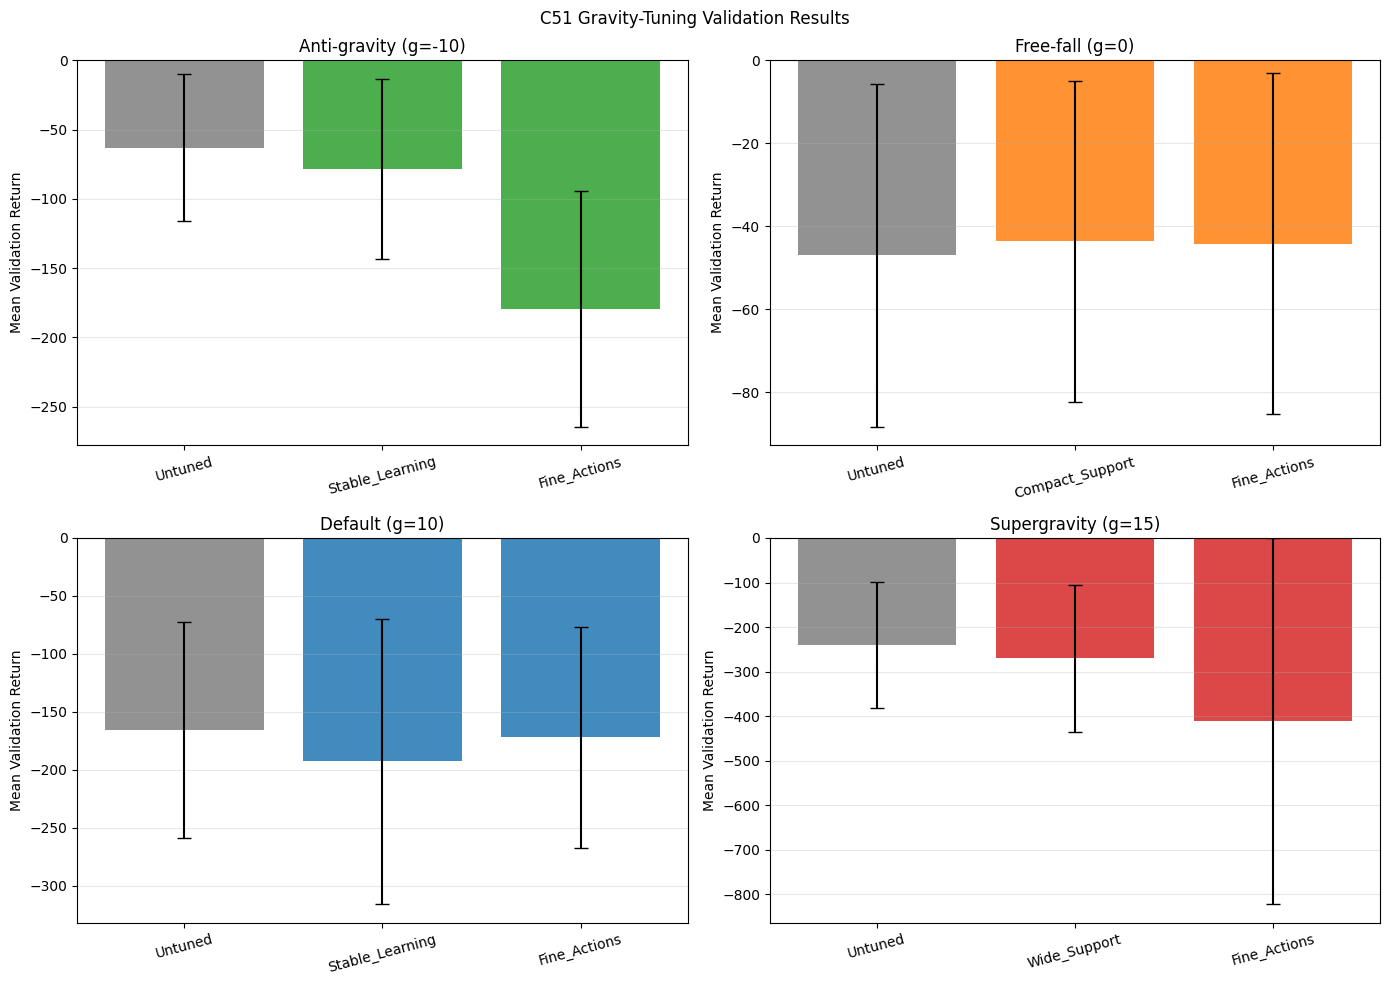

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for axis_index, axis in enumerate(axes.flat):
    if axis_index >= len(GRAVITIES_TO_TUNE):
        axis.axis("off")
        continue

    gravity_name = GRAVITIES_TO_TUNE[axis_index]
    trial_data = tuning_validation_returns[gravity_name]
    trial_names = list(trial_data.keys())
    means = [np.mean(trial_data[name]) for name in trial_names]
    stds = [np.std(trial_data[name]) for name in trial_names]

    colours = [
        "tab:gray" if name == "Untuned" else GRAVITY_COLOURS[gravity_name]
        for name in trial_names
    ]

    axis.bar(trial_names, means, yerr=stds, capsize=5, color=colours, alpha=0.85)
    axis.set_title(f"{GRAVITY_LABELS[gravity_name]} ({gravity_name})")
    axis.set_ylabel("Mean Validation Return")
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.3)

plt.suptitle("C51 Gravity-Tuning Validation Results")
plt.tight_layout()
plt.show()


### Gravity-Specific Tuning Results

#### Anti-gravity

The untuned configuration achieved the best mean validation return of -63.11. Stable Learning achieved -78.45, while Fine Actions achieved -179.65. Therefore, neither tuning configuration improved Anti-gravity performance.

#### Free-fall

Compact Support achieved the best mean validation return of -43.63, compared with -46.98 for Untuned and -44.17 for Fine Actions. Compact Support was therefore selected, although its advantage was relatively small.

#### Default Gravity

The untuned configuration achieved the best mean return of -165.56. Fine Actions achieved -172.13 and Stable Learning achieved -192.91. Therefore, the original configuration remained the most suitable for Default gravity.

#### Supergravity

The untuned configuration achieved the best mean return of -239.28. Wide Support achieved -270.44, while Fine Actions achieved -411.31 with very high variability. The original support range and action count were therefore retained.

Overall, gravity-specific tuning only improved validation performance for Free-fall. The original configuration remained superior for the other three conditions.

## Selected Hyperparameters


In [30]:
KEY_PARAMETERS = [
    "learning_rate",
    "epsilon_decay",
    "num_actions",
    "v_min",
    "v_max",
    "hidden_size",
    "batch_size"
]

print("Selected C51 configuration for each tuned gravity")
print("=" * 110)

for gravity_name in GRAVITIES_TO_TUNE:
    result = selected_results[gravity_name]
    print(
        f"\n{GRAVITY_LABELS[gravity_name]} ({gravity_name}) "
        f"-> {selected_trial_names[gravity_name]}"
    )

    for parameter in KEY_PARAMETERS:
        print(f"  {parameter:<20}: {result['config'][parameter]}")


Selected C51 configuration for each tuned gravity

Anti-gravity (g=-10) -> Untuned
  learning_rate       : 0.001
  epsilon_decay       : 0.98
  num_actions         : 40
  v_min               : -2500.0
  v_max               : 0.0
  hidden_size         : 64
  batch_size          : 32

Free-fall (g=0) -> Compact_Support
  learning_rate       : 0.0005
  epsilon_decay       : 0.98
  num_actions         : 40
  v_min               : -1500.0
  v_max               : 0.0
  hidden_size         : 64
  batch_size          : 32

Default (g=10) -> Untuned
  learning_rate       : 0.001
  epsilon_decay       : 0.98
  num_actions         : 40
  v_min               : -2500.0
  v_max               : 0.0
  hidden_size         : 64
  batch_size          : 32

Supergravity (g=15) -> Untuned
  learning_rate       : 0.001
  epsilon_decay       : 0.98
  num_actions         : 40
  v_min               : -2500.0
  v_max               : 0.0
  hidden_size         : 64
  batch_size          : 32


### Selected Gravity-Specific Configurations

| Gravity | Selected trial | Learning rate | Epsilon decay | Actions | Minimum support |
|---|---|---:|---:|---:|---:|
| Anti-gravity | Untuned | 0.0010 | 0.98 | 40 | -2500 |
| Free-fall | Compact Support | 0.0005 | 0.98 | 40 | -1500 |
| Default | Untuned | 0.0010 | 0.98 | 40 | -2500 |
| Supergravity | Untuned | 0.0010 | 0.98 | 40 | -2500 |

Compact Support was selected only for Free-fall. Its minimum distributional support was increased from -2500 to -1500, producing a narrower return range that was more suitable for the generally less-negative Free-fall returns.

For Anti-gravity, Default and Supergravity, none of the tested alternatives surpassed the original configuration. Their untuned parameters were therefore retained.

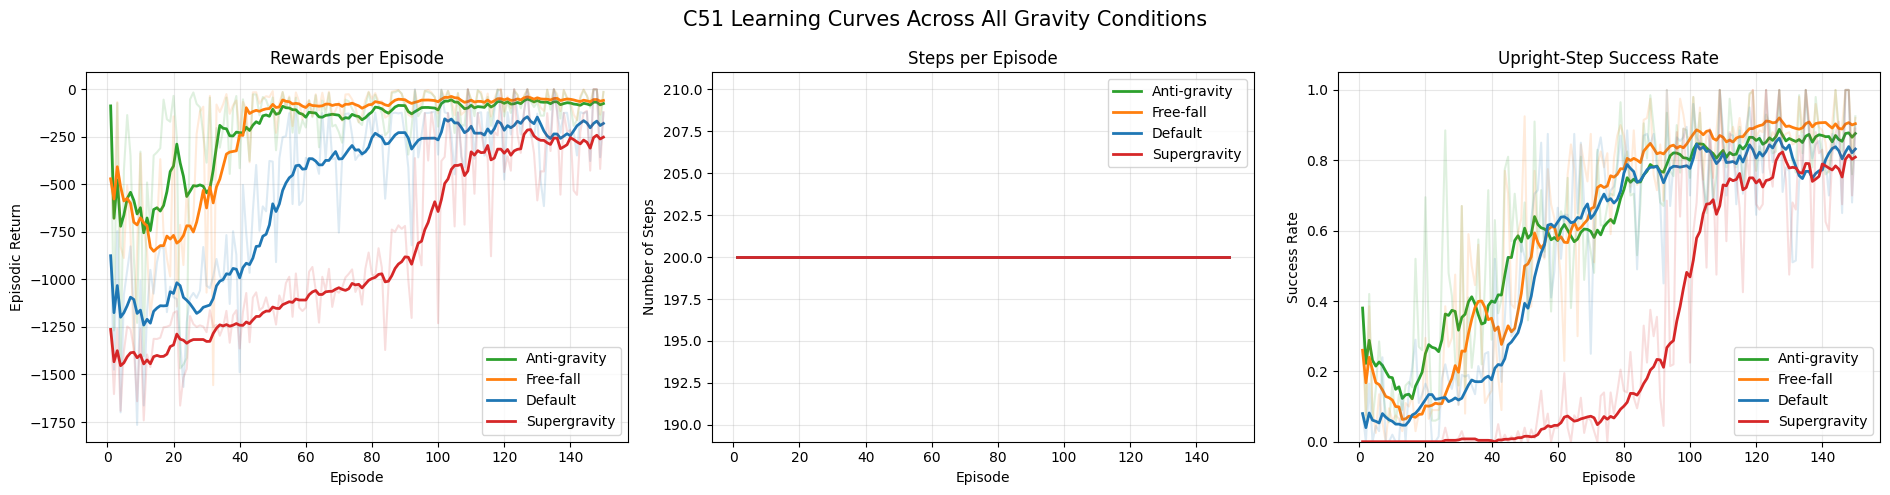

In [38]:
# Three Learning-Curve Graphs for All Four Gravities

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for gravity_name in GRAVITIES_TO_TUNE:
    result = selected_results[gravity_name]
    history = result["history"]

    episodes = np.arange(1, len(history["returns"]) + 1)
    colour = GRAVITY_COLOURS[gravity_name]
    label = GRAVITY_LABELS[gravity_name]

    # 1. Rewards per Episode
    axes[0].plot(
        episodes,
        history["returns"],
        color=colour,
        alpha=0.15
    )
    axes[0].plot(
        episodes,
        history["moving_avg_returns"],
        color=colour,
        linewidth=2,
        label=label
    )

    # 2. Steps per Episode
    axes[1].plot(
        episodes,
        history["episode_lengths"],
        color=colour,
        linewidth=2,
        label=label
    )

    # 3. Success Rate
    # Success is defined as the proportion of steps where cos(theta) > 0.95.
    success_rate = (
        np.asarray(history["upright_percentages"]) / 100.0
    )

    smoothed_success_rate = np.array([
        np.mean(success_rate[max(0, i - 9):i + 1])
        for i in range(len(success_rate))
    ])

    axes[2].plot(
        episodes,
        success_rate,
        color=colour,
        alpha=0.15
    )
    axes[2].plot(
        episodes,
        smoothed_success_rate,
        color=colour,
        linewidth=2,
        label=label
    )


# Rewards graph
axes[0].set_title("Rewards per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Episodic Return")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Steps graph
axes[1].set_title("Steps per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Number of Steps")
axes[1].grid(alpha=0.3)
axes[1].legend()

# Success-rate graph
axes[2].set_title("Upright-Step Success Rate")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Success Rate")
axes[2].set_ylim(0, 1.05)
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.suptitle(
    "C51 Learning Curves Across All Gravity Conditions",
    fontsize=15
)
plt.tight_layout()
plt.show()

### Interpretation of C51 Learning Curves

#### Rewards per Episode

The episodic returns improved across all four gravity conditions, showing that the C51 agents learned more effective control policies.

Anti-gravity and Free-fall improved most quickly and achieved returns closest to zero. Default gravity required more episodes to improve, while Supergravity experienced the slowest learning and remained the most negative at the end of training.

The lighter lines represent individual episode returns and show that performance continued to fluctuate. The darker 10-episode moving averages show the overall learning trend more clearly.

#### Steps per Episode

All four gravity conditions remained at 200 steps per episode. Their lines overlap completely, which is why only the final plotted red line is visible.

Pendulum episodes end after the fixed 200-step time limit rather than when the agent succeeds or fails. Therefore, the constant episode length confirms that every agent received the same interaction budget, but it does not measure model improvement.

#### Upright-Step Success Rate

The upright-step success rate represents the proportion of steps where the pendulum was near the upright position, defined as cos(theta) greater than 0.95.

Success rates increased under all four gravity conditions. Free-fall achieved the highest final success rate at approximately 0.90, followed closely by Anti-gravity and Default gravity. Supergravity improved more slowly and only increased sharply after approximately Episode 85.

The slower improvement under Supergravity is consistent with its more negative rewards. Its stronger gravitational force made it more difficult for the agent to raise and maintain the pendulum near the upright position.

Overall, the increasing rewards and success rates demonstrate that C51 learned useful control policies across all four gravity conditions.

# Part 3: Final Held-Out Evaluation


The final comparison uses seeds 2000–2029. These seeds were not used during training or tuning selection. For every gravity, the untuned and selected agents are evaluated on the same initial states.

Because Pendulum returns are negative, a return closer to zero indicates better control. Improvement is calculated as:

$$
\text{Improvement}=\text{Tuned Mean}-\text{Untuned Mean}
$$


In [31]:
untuned_final_returns = {}
selected_final_returns = {}
final_statistics = {}

for gravity_name in GRAVITIES_TO_TUNE:
    untuned_returns = evaluate_trained_result(
        untuned_results[gravity_name],
        FINAL_TEST_SEEDS
    )
    selected_returns = evaluate_trained_result(
        selected_results[gravity_name],
        FINAL_TEST_SEEDS
    )

    untuned_final_returns[gravity_name] = untuned_returns
    selected_final_returns[gravity_name] = selected_returns

    untuned_stats = return_statistics(untuned_returns)
    selected_stats = return_statistics(selected_returns)

    final_statistics[gravity_name] = {
        "untuned": untuned_stats,
        "tuned": selected_stats,
        "improvement": selected_stats["mean"] - untuned_stats["mean"],
        "selected_trial": selected_trial_names[gravity_name]
    }

print("FINAL HELD-OUT EVALUATION")
print("=" * 118)
print(
    f"{'Gravity':<16}{'Selected Trial':<22}"
    f"{'Untuned Mean':>15}{'Tuned Mean':>15}"
    f"{'Improvement':>15}{'Tuned Std':>13}"
)
print("-" * 118)

for gravity_name, stats in final_statistics.items():
    print(
        f"{GRAVITY_LABELS[gravity_name]:<16}"
        f"{stats['selected_trial']:<22}"
        f"{stats['untuned']['mean']:>15.2f}"
        f"{stats['tuned']['mean']:>15.2f}"
        f"{stats['improvement']:>15.2f}"
        f"{stats['tuned']['std']:>13.2f}"
    )


FINAL HELD-OUT EVALUATION
Gravity         Selected Trial           Untuned Mean     Tuned Mean    Improvement    Tuned Std
----------------------------------------------------------------------------------------------------------------------
Anti-gravity    Untuned                        -62.30         -62.30           0.00        52.16
Free-fall       Compact_Support                -51.21         -48.65           2.56        41.67
Default         Untuned                       -183.08        -183.08           0.00       135.15
Supergravity    Untuned                       -230.72        -230.72           0.00       157.06


### Final Held-Out Evaluation

The selected agents were evaluated across 30 unseen episodes using seeds 2000 to 2029.

| Gravity | Selected trial | Untuned mean | Selected mean | Improvement | Selected standard deviation |
|---|---|---:|---:|---:|---:|
| Anti-gravity | Untuned | -62.30 | -62.30 | 0.00 | 52.16 |
| Free-fall | Compact Support | -51.21 | -48.65 | +2.56 | 41.67 |
| Default | Untuned | -183.08 | -183.08 | 0.00 | 135.15 |
| Supergravity | Untuned | -230.72 | -230.72 | 0.00 | 157.06 |

Free-fall was the only environment where a tuned configuration was selected. Compact Support improved its mean return by 2.56 points.

The improvement was small compared with the standard deviation of 41.67. Therefore, the result indicates a modest benefit rather than a large or conclusive improvement.

The remaining three environments have an improvement of zero because the untuned model was selected during validation.

## Final Reward Comparison


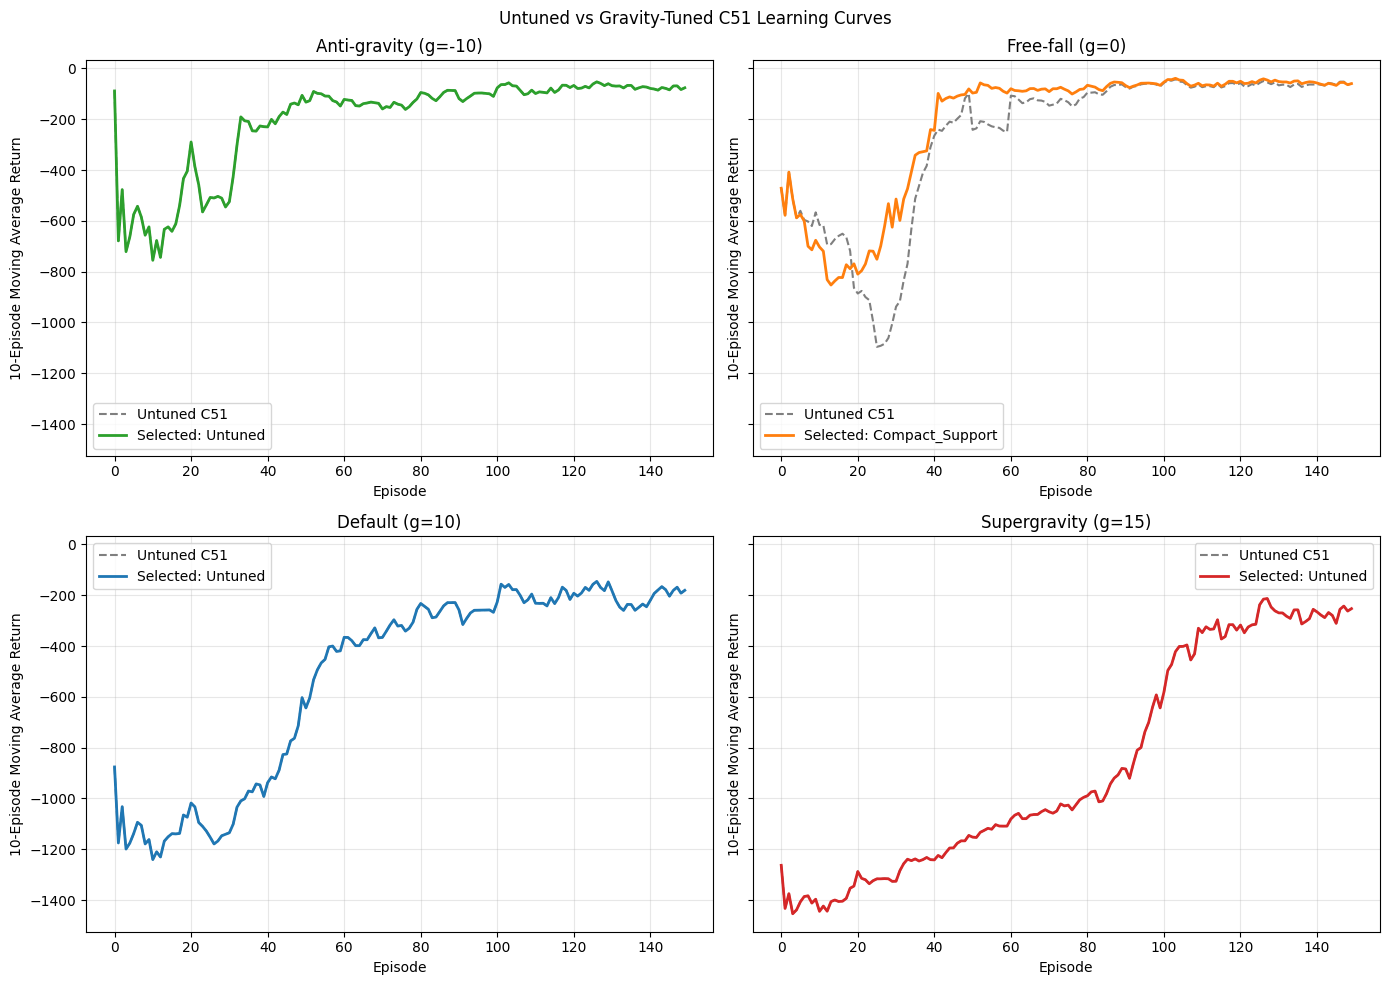

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for axis_index, axis in enumerate(axes.flat):
    if axis_index >= len(GRAVITIES_TO_TUNE):
        axis.axis("off")
        continue

    gravity_name = GRAVITIES_TO_TUNE[axis_index]
    untuned_history = untuned_results[gravity_name]["history"]
    selected_history = selected_results[gravity_name]["history"]

    axis.plot(
        untuned_history["moving_avg_returns"],
        linestyle="--",
        color="tab:gray",
        label="Untuned C51"
    )
    axis.plot(
        selected_history["moving_avg_returns"],
        linewidth=2,
        color=GRAVITY_COLOURS[gravity_name],
        label=f"Selected: {selected_trial_names[gravity_name]}"
    )
    axis.set_title(f"{GRAVITY_LABELS[gravity_name]} ({gravity_name})")
    axis.set_xlabel("Episode")
    axis.set_ylabel("10-Episode Moving Average Return")
    axis.grid(alpha=0.3)
    axis.legend()

plt.suptitle("Untuned vs Gravity-Tuned C51 Learning Curves")
plt.tight_layout()
plt.show()


### Untuned and Selected Learning-Curve Comparison

For Anti-gravity, Default and Supergravity, the selected model was the original untuned configuration. Consequently, the untuned and selected learning curves overlap completely.

For Free-fall, Compact Support recovered from its early poor returns more quickly than the untuned configuration. Both configurations eventually converged to similar returns near zero, but Compact Support achieved a slightly better held-out mean.

The graph demonstrates that environment-specific tuning was not automatically beneficial. A tuned configuration was retained only when it achieved better validation performance.


## Final Loss Comparison


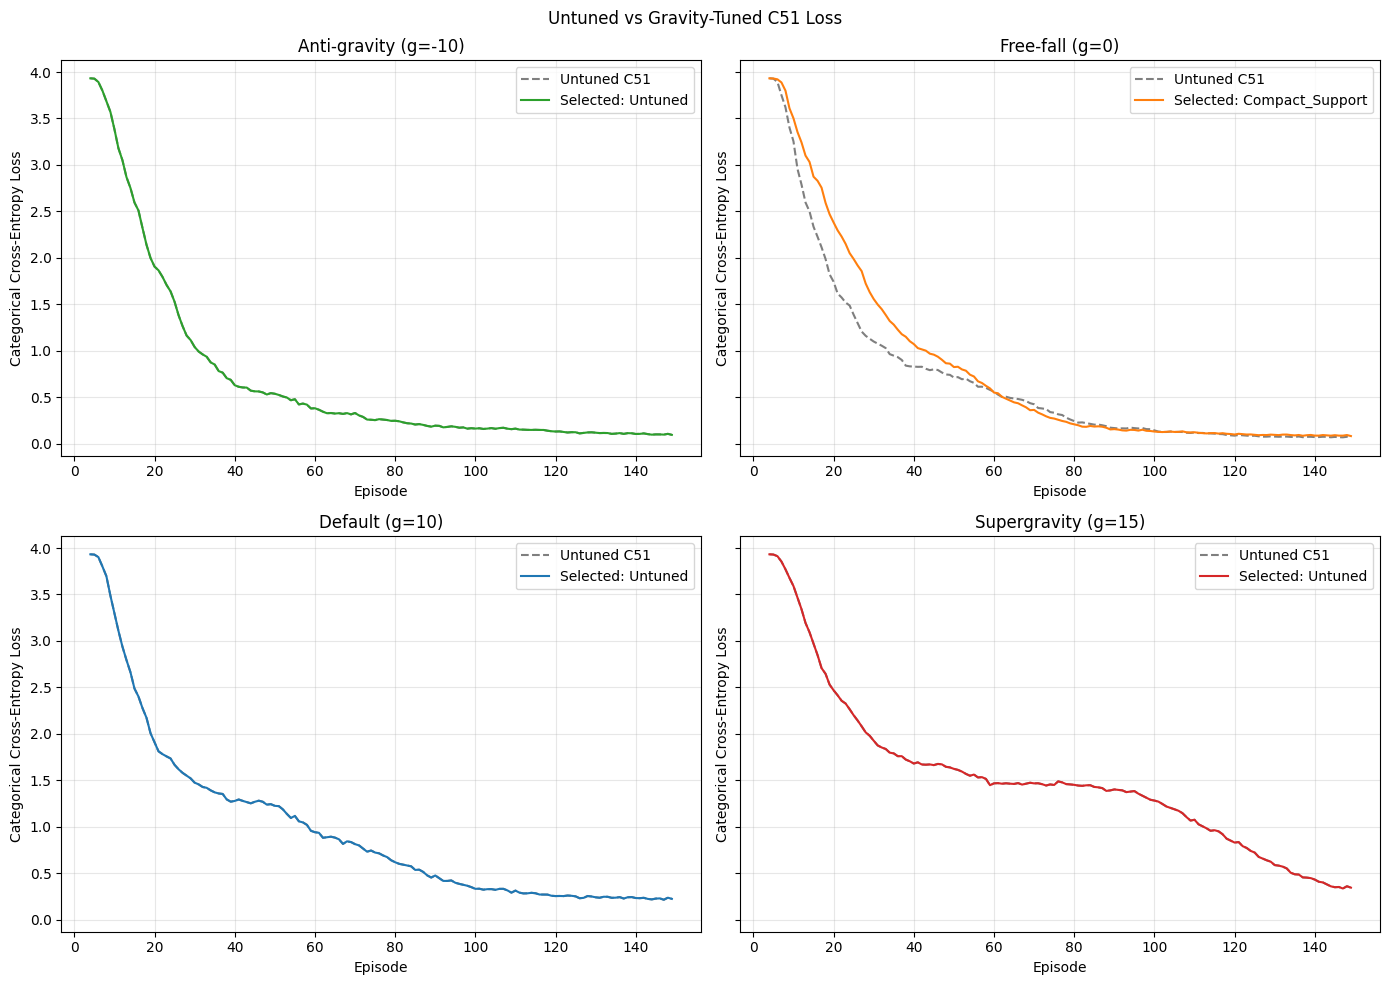

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for axis_index, axis in enumerate(axes.flat):
    if axis_index >= len(GRAVITIES_TO_TUNE):
        axis.axis("off")
        continue

    gravity_name = GRAVITIES_TO_TUNE[axis_index]
    axis.plot(
        untuned_results[gravity_name]["history"]["losses"],
        linestyle="--",
        color="tab:gray",
        label="Untuned C51"
    )
    axis.plot(
        selected_results[gravity_name]["history"]["losses"],
        color=GRAVITY_COLOURS[gravity_name],
        label=f"Selected: {selected_trial_names[gravity_name]}"
    )
    axis.set_title(f"{GRAVITY_LABELS[gravity_name]} ({gravity_name})")
    axis.set_xlabel("Episode")
    axis.set_ylabel("Categorical Cross-Entropy Loss")
    axis.grid(alpha=0.3)
    axis.legend()

plt.suptitle("Untuned vs Gravity-Tuned C51 Loss")
plt.tight_layout()
plt.show()


### Untuned and Selected Loss Comparison

The loss curves overlap for Anti-gravity, Default and Supergravity because their untuned configurations were retained.

For Free-fall, Compact Support initially had a higher loss than the untuned configuration. However, both loss curves decreased steadily and converged to similarly low values by the end of training.

This shows that the narrower C51 support still learned a stable return distribution. However, lower training loss alone was not used to select the model; selection was based on greedy validation return.

## Final Evaluation Boxplots


C:\Users\kayde\AppData\Local\Temp\ipykernel_40612\595895955.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
C:\Users\kayde\AppData\Local\Temp\ipykernel_40612\595895955.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
C:\Users\kayde\AppData\Local\Temp\ipykernel_40612\595895955.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
C:\Users\kayde\AppData\Local\Temp\ipykernel_40612\595895955.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxpl

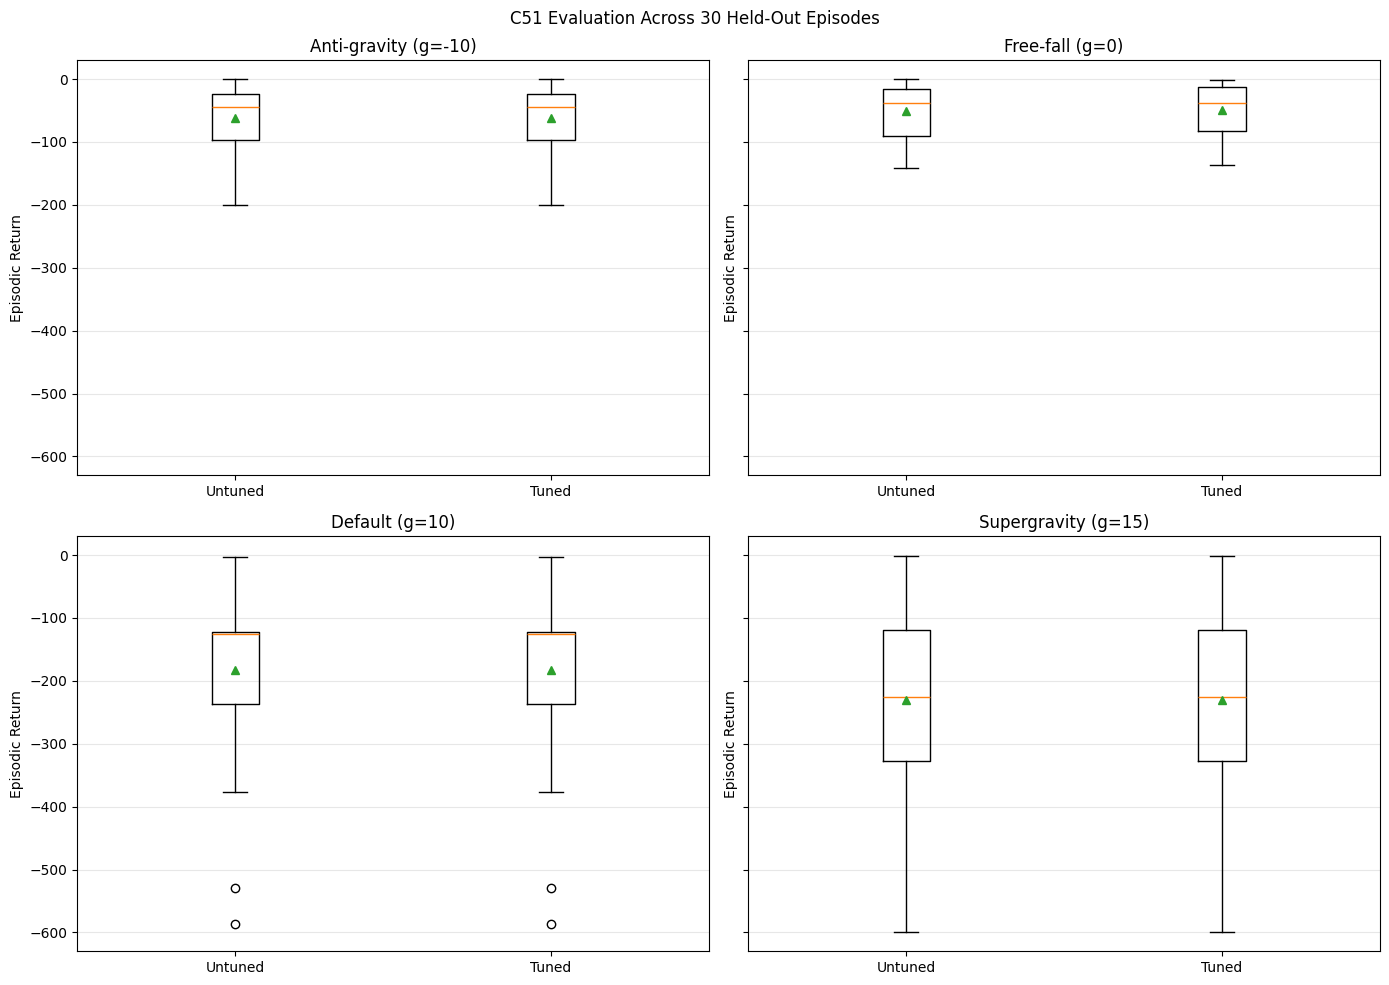

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for axis_index, axis in enumerate(axes.flat):
    if axis_index >= len(GRAVITIES_TO_TUNE):
        axis.axis("off")
        continue

    gravity_name = GRAVITIES_TO_TUNE[axis_index]
    axis.boxplot(
        [
            untuned_final_returns[gravity_name],
            selected_final_returns[gravity_name]
        ],
        labels=["Untuned", "Tuned"],
        showmeans=True
    )
    axis.set_title(f"{GRAVITY_LABELS[gravity_name]} ({gravity_name})")
    axis.set_ylabel("Episodic Return")
    axis.grid(axis="y", alpha=0.3)

plt.suptitle("C51 Evaluation Across 30 Held-Out Episodes")
plt.tight_layout()
plt.show()


### Final Evaluation Boxplot Interpretation

The Anti-gravity boxplots are identical because the untuned agent remained selected. Returns were generally concentrated closer to zero, although some episodes fell to approximately -200.

For Free-fall, the Compact Support model produced a slightly higher mean return than the untuned model. However, their distributions overlap substantially, confirming that the improvement was modest.

Default gravity showed a wider return distribution and several poor outliers below -500. This indicates that the agent occasionally struggled with difficult initial states.

Supergravity displayed the largest spread, with returns ranging from values near zero to approximately -600. Its high variability confirms that it remained the most challenging environment.

Overall, Free-fall produced the strongest selected-model performance, while Supergravity produced the greatest uncertainty and poorest consistency.

# Saving Final Weights and Results


All training checkpoints already reside inside `c51_weights/`. The following cell also saves one clearly named final weight file per selected gravity inside `c51_weights/final_selected/` and exports the numerical results for consolidation.


In [36]:
OUTPUT_DIR = Path("PtBkaydenC51_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

final_weight_paths = {}

for gravity_name, result in selected_results.items():
    final_path = FINAL_WEIGHTS_DIR / (
        f"c51_{safe_name(gravity_name)}_final.weights.h5"
    )
    result["agent"].model.save_weights(str(final_path))
    final_weight_paths[gravity_name] = str(final_path)

serialisable_summary = {}

for gravity_name, stats in final_statistics.items():
    serialisable_summary[gravity_name] = {
        **stats,
        "gravity_label": GRAVITY_LABELS[gravity_name],
        "selected_config": {
            key: (
                value.item()
                if isinstance(value, np.generic)
                else value
            )
            for key, value in selected_results[gravity_name]["config"].items()
        },
        "final_weight_path": final_weight_paths[gravity_name]
    }

with (OUTPUT_DIR / "c51_tuning_summary.json").open("w", encoding="utf-8") as file:
    json.dump(serialisable_summary, file, indent=2)

np.savez_compressed(
    OUTPUT_DIR / "c51_final_evaluation_returns.npz",
    **{
        f"{safe_name(gravity_name)}_untuned": untuned_final_returns[gravity_name]
        for gravity_name in GRAVITIES_TO_TUNE
    },
    **{
        f"{safe_name(gravity_name)}_tuned": selected_final_returns[gravity_name]
        for gravity_name in GRAVITIES_TO_TUNE
    }
)

print("Final selected weights")
for gravity_name, path in final_weight_paths.items():
    print(f"{GRAVITY_LABELS[gravity_name]:<16}: {path}")

print("\nSaved result files:")
print(OUTPUT_DIR / "c51_tuning_summary.json")
print(OUTPUT_DIR / "c51_final_evaluation_returns.npz")


Final selected weights
Anti-gravity    : PtBkaydenC51_weights\final_selected\c51_gneg10_final.weights.h5
Free-fall       : PtBkaydenC51_weights\final_selected\c51_g0_final.weights.h5
Default         : PtBkaydenC51_weights\final_selected\c51_g10_final.weights.h5
Supergravity    : PtBkaydenC51_weights\final_selected\c51_g15_final.weights.h5

Saved result files:
PtBkaydenC51_results\c51_tuning_summary.json
PtBkaydenC51_results\c51_final_evaluation_returns.npz


# Optional: Single-Episode Trajectory Analysis


In [37]:
def plot_selected_trajectory(gravity_name, seed=3000):
    result = selected_results[gravity_name]
    agent = result["agent"]
    action_values = result["action_values"]
    config = result["config"]
    env = create_env(config["gravity"])
    state = reset_environment(env, seed=seed)

    cosines = []
    angular_velocities = []
    torques = []
    rewards = []
    done = False

    while not done:
        action_index = agent.act(state, explore=False)
        torque = action_index_to_torque(action_index, action_values)

        cosines.append(float(state[0]))
        angular_velocities.append(float(state[2]))
        torques.append(float(torque[0]))

        state, reward, done, _ = step_environment(env, torque)
        rewards.append(reward)

    env.close()

    fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
    axes[0].plot(cosines)
    axes[0].axhline(0.95, color="red", linestyle="--", label="Near-upright threshold")
    axes[0].set_ylabel("cos(theta)")
    axes[0].legend()

    axes[1].plot(angular_velocities)
    axes[1].set_ylabel("Scaled Angular Velocity")

    axes[2].plot(torques)
    axes[2].set_ylabel("Torque")

    axes[3].plot(np.cumsum(rewards))
    axes[3].set_ylabel("Cumulative Return")
    axes[3].set_xlabel("Time Step")

    for axis in axes:
        axis.grid(alpha=0.3)

    plt.suptitle(
        f"Selected C51 Trajectory — {GRAVITY_LABELS[gravity_name]} ({gravity_name})"
    )
    plt.tight_layout()
    plt.show()


RUN_TRAJECTORY_PLOTS = False

if RUN_TRAJECTORY_PLOTS:
    for gravity_name in GRAVITIES_TO_TUNE:
        plot_selected_trajectory(gravity_name)
else:
    print("Set RUN_TRAJECTORY_PLOTS = True to generate trajectory plots.")


Set RUN_TRAJECTORY_PLOTS = True to generate trajectory plots.


## Final Conclusion

A C51 Distributional DQN was trained and evaluated under Anti-gravity, Free-fall, Default and Supergravity conditions. The untuned C51 successfully improved its return and reduced its categorical loss across all four environments.

Gravity-specific tuning improved held-out performance in only one of the four environments. Free-fall selected the Compact Support configuration, which used a learning rate of 0.0005 and a narrower distributional support from -1500 to 0. It improved the mean held-out return from -51.21 to -48.65.

The untuned configuration remained the best choice for Anti-gravity, Default and Supergravity. This demonstrates that changing hyperparameters does not necessarily improve reinforcement-learning performance and that each configuration must be evaluated using unseen episodes.

Among the four environments, Free-fall produced the best final mean return of -48.65. Supergravity produced the poorest mean return of -230.72 and the highest standard deviation of 157.06, making it the most difficult and inconsistent gravity condition.

Overall, C51 provided effective pendulum control across all four gravity conditions. However, the usefulness of environment-specific tuning depended on the gravity setting, with only Free-fall benefiting from the tested parameter changes.
